In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

### Load the Fashion-MNIST dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Dataset loaded successfully.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully.


### Display dataset statistics

Number of training images: (60000, 28, 28)
Number of training labels: (60000,)
First 5 training labels: [9 0 0 3 0]
Number of testing images: (10000, 28, 28)
Number of testing labels: (10000,)
Image dimensions: (28, 28)


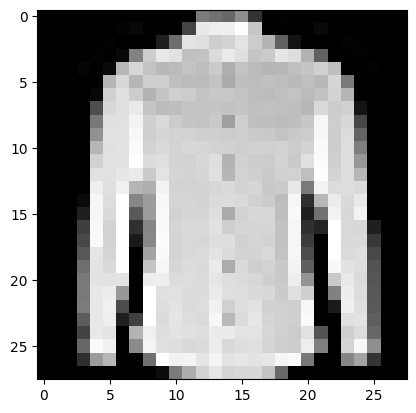

In [ ]:
print(f"Number of training images: {X_train.shape}")
print(f"Number of training labels: {y_train.shape}")
print(f"First 5 training labels: {y_train[0:5]}")
print(f"Number of testing images: {X_test.shape}")
print(f"Number of testing labels: {y_test.shape}")
print(f"Image dimensions: {X_train.shape[1:]}")

#visualizing a sample image from the data
plt.imshow(X_train[895], cmap='gray')
plt.show()

### Normalize the image pixel values

In [ ]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print(f"Image pixel values normalized to [0, 1]: {X_train_norm.min(), X_train_norm.max()}")


Image pixel values normalized to [0, 1]: (np.float32(0.0), np.float32(1.0))


### Reshape the images for CNN layers

In [ ]:
# Fashion-MNIST images are grayscale, so they have 1 channel.
X_train_shaped = X_train_norm.reshape(-1, 28, 28, 1)
X_test_shaped = X_test_norm.reshape(-1, 28, 28, 1)

print(f"Training images reshaped to: {X_train_shaped.shape}")
print(f"Testing images reshaped to: {X_test_shaped.shape}")

one_image=X_train_norm[0:1]
print(one_image)

Training images reshaped to: (60000, 28, 28, 1)
Testing images reshaped to: (10000, 28, 28, 1)
[[[0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.  

### Display sample images along with their class labels

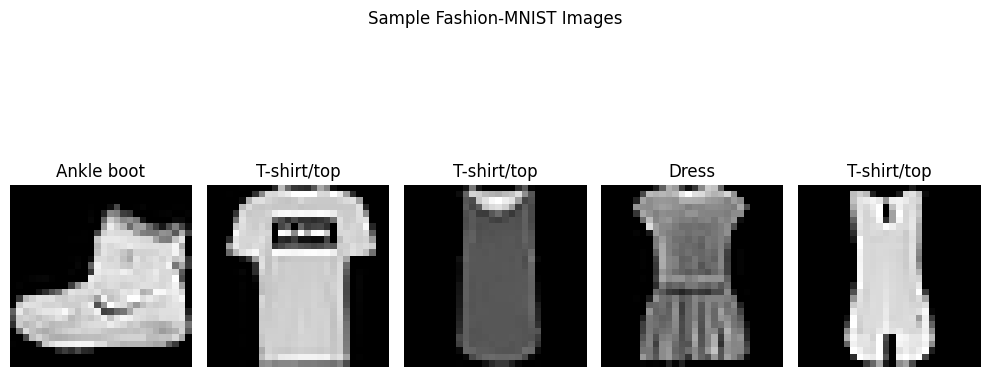

In [22]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(1, 5, i + 1) # Changed to 1 row, 5 columns
    plt.imshow(X_train_shaped[i].reshape(28, 28), cmap='gray') # Reshape back for display
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle('Sample Fashion-MNIST Images', y=0.75) # Adjust y for title placement
plt.tight_layout()
plt.show()

### Create a Convolutional Neural Network (CNN) model

In [ ]:
model = models.Sequential([
    layers.Input(shape=(28,28,1), name="input_layer"),
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', name="conv_layer_1"),
    layers.MaxPooling2D(pool_size=(2,2), name="max_pool_1"),
    layers.Conv2D(filters=64,  kernel_size=(3, 3), activation='relu', name="conv_layer_2"),
    layers.MaxPooling2D(pool_size=(2,2), name="max_pool_2"),
    layers.Flatten(),
    layers.Dense(128, activation='relu', name="hidden_layer_1"),
    layers.Dense(len(class_names), activation='softmax',name="output_layer") # Output layer with number of classes
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer_1 (Conv2D)           │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Train the CNN model

In [13]:
history = model.fit(X_train_shaped, y_train, epochs=20, batch_size=64, validation_split=0.2)

print(f"Training history: {history}")

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.8147 - loss: 0.5132 - val_accuracy: 0.8601 - val_loss: 0.3934
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8771 - loss: 0.3389 - val_accuracy: 0.8846 - val_loss: 0.3155
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.8930 - loss: 0.2908 - val_accuracy: 0.8894 - val_loss: 0.3087
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9066 - loss: 0.2565 - val_accuracy: 0.9010 - val_loss: 0.2751
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9139 - loss: 0.2338 - val_accuracy: 0.9059 - val_loss: 0.2601
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9203 - loss: 0.2143 - val_accuracy: 0.9051 - val_loss: 0.2573
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9279 - loss: 0.1959 - val_accuracy: 0.9119 - val_loss: 0.2487
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9346 - loss: 0.1751 - 

### Evaluate the trained CNN model

In [14]:
test_loss, test_accuracy = model.evaluate(X_test_shaped, y_test)
print(f'\nTest accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9075 - loss: 0.4099

Test accuracy: 0.9075
Test loss: 0.4099


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Displaying predictions for the first 10 test images:


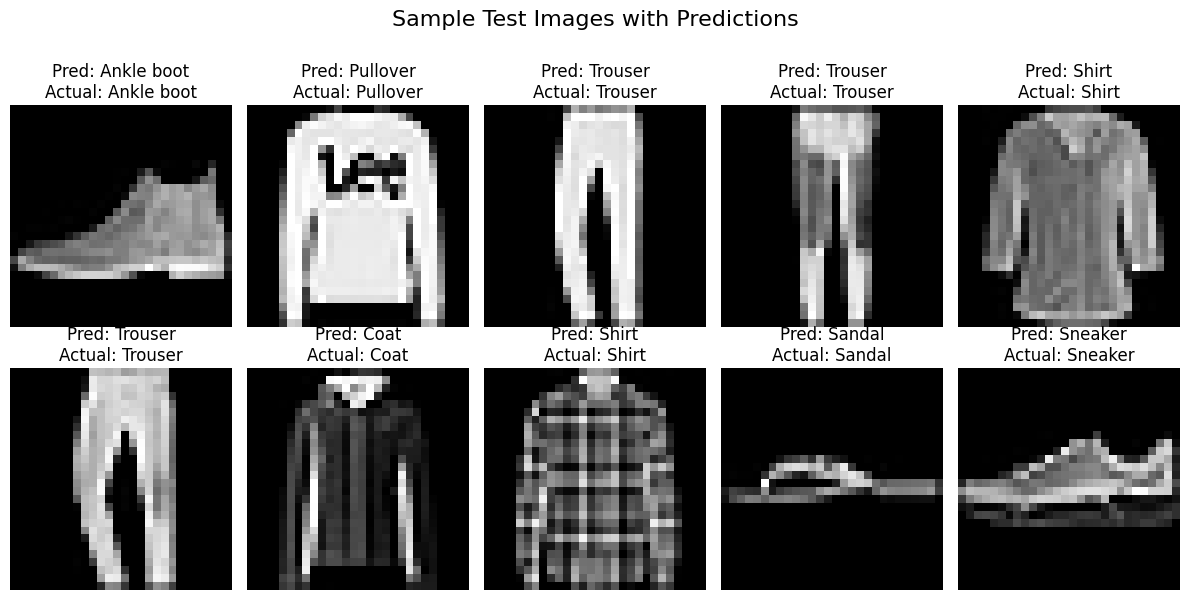

In [21]:
predictions = model.predict(X_test_shaped)
predicted_labels = np.argmax(predictions, axis=1)

print("Displaying predictions for the first 10 test images:")
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_shaped[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {class_names[predicted_labels[i]]}\nActual: {class_names[y_test[i]]}")
    plt.axis('off')
plt.suptitle('Sample Test Images with Predictions', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


Confusion Matrix:
[[890   0  14  15   0   1  68   0  12   0]
 [  6 969   2  17   2   0   0   0   4   0]
 [ 21   0 881   6  40   0  49   0   3   0]
 [ 19   2  23 894  29   0  25   0   8   0]
 [  2   0  65  22 852   0  53   0   6   0]
 [  0   0   0   0   0 973   0  21   3   3]
 [135   0  71  20  57   0 706   0  11   0]
 [  0   0   0   0   0   3   0 966   1  30]
 [  2   0   5   3   0   1   2   1 986   0]
 [  1   0   0   0   0   5   0  35   1 958]]


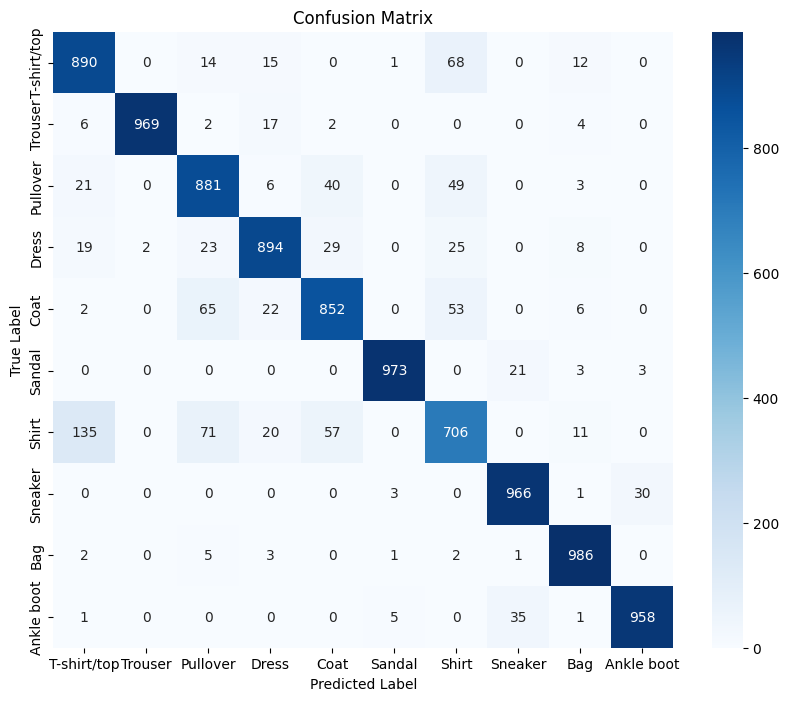

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, predicted_labels)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [19]:
print("\nClassification Report:")
print(classification_report(y_test, predicted_labels, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.89      0.86      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.83      0.88      0.85      1000
       Dress       0.92      0.89      0.90      1000
        Coat       0.87      0.85      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.78      0.71      0.74      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.95      0.99      0.97      1000
  Ankle boot       0.97      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



 ### Model Analysis

1. Why are CNNs more suitable than Artificial Neural Networks (ANNs) for image
classification?

#### CNNs retain spatial relationships between neighboring pixels using shared weights, whereas standard ANNs flatten images into 1D vectors, losing spatial context and drastically increasing parameters.


2. What is the purpose of a Convolution layer?

#### It applies learnable filters to input images to automatically extract key local features like edges, textures, and patterns.

3. Why is Max Pooling used in CNNs?

#### It reduces spatial dimensions to decrease computational load and parameter count while making feature detection invariant to small translations and distortions.

4. Why is the Flatten layer required before the Dense layers?

#### It converts multidimensional feature maps into a 1D vector format required as input by fully connected Dense layers.

5. Why is the Softmax activation function used in the output layer?

#### It transforms raw model outputs (logits) into a probability distribution over multiple classes that sums to 1 for final classification.

6. How does the Adam optimizer help in training the CNN?

#### It combines adaptive learning rates for each parameter with momentum, accelerating convergence and preventing training from getting stuck in local minima.